# Dataset Exploration

Exploratory analysis of the two siRNA datasets:

1. **Historic dataset** &mdash; `dataset/Historic_Takayuki_hueskan_ichihara.csv`, a
   table combining three source datasets (Huesken, Takayuki, ichihara_mix).
2. **Primary dataset** &mdash; `dataset/primary_dataset/CMsiRNA_data_update.tsv`, the merge of the
   per-gene `patent_dataset_<GENE>.tsv` files?

### Mount folder in Colab
Uncomment the following cell to mount Google Drive if running this notebook in Google Colab. When running locally you can leave it commented out.

Also, please download the `dataset` folder located on the general level of our shared folder to the local Drive folder `/MyDrive/mlrg/`. I was not able to find a solution to mount directly to the folders in the "Shared with me" section.

In [1]:
"""
from google.colab import drive
import os

gdrive_path = '/content/gdrive/MyDrive/mlrg/'

# This will mount your google drive under 'MyDrive'
drive.mount('/content/gdrive', force_remount=True)
# In order to access the files in this notebook we have to navigate to the correct folder
os.chdir(gdrive_path)
# Check manually if all files are present
print(sorted(os.listdir()))
"""

"\nfrom google.colab import drive\nimport os\n\ngdrive_path = '/content/gdrive/MyDrive/mlrg/'\n\n# This will mount your google drive under 'MyDrive'\ndrive.mount('/content/gdrive', force_remount=True)\n# In order to access the files in this notebook we have to navigate to the correct folder\nos.chdir(gdrive_path)\n# Check manually if all files are present\nprint(sorted(os.listdir()))\n"

## Setup
Imports, dataset-path resolution (works both locally and in Colab), and reusable helper functions used throughout the notebook.

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import glob
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')

In [4]:
# Resolve the dataset directory so the notebook runs locally and in Colab.
_CANDIDATES = [
    Path('../../dataset'),
    Path('/content/gdrive/MyDrive/mlrg/dataset'),
    Path('content/gdrive/MyDrive/mlrg/dataset'),
]
DATA_DIR = next((p for p in _CANDIDATES if p.exists()), Path('../../dataset'))
PRIMARY_DIR = DATA_DIR / 'primary_dataset'
HISTORIC_CSV = DATA_DIR / 'Historic_Takayuki_hueskan_ichihara.csv'
UPDATE_TSV = PRIMARY_DIR / 'CMsiRNA_data_update.tsv'

print('DATA_DIR    =', DATA_DIR.resolve())
print('PRIMARY_DIR =', PRIMARY_DIR.resolve())

DATA_DIR    = /Users/mac/Library/Mobile Documents/com~apple~CloudDocs/Master/MLRG/p14-crew/dataset
PRIMARY_DIR = /Users/mac/Library/Mobile Documents/com~apple~CloudDocs/Master/MLRG/p14-crew/dataset/primary_dataset


In [5]:
NUC = ['A', 'U', 'G', 'C']
_COMP = {'A': 'U', 'U': 'A', 'T': 'A', 'G': 'C', 'C': 'G'}


def describe_dataset(df, name='dataset'):
    """Print basic shape information."""
    print(f'{name}: {df.shape[0]:,} samples (rows) x {df.shape[1]} columns')


def column_summary(df, max_list=10):
    """Per-column dtype, #unique, unique values (if < max_list), and % missing."""
    rows = []
    for col in df.columns:
        s = df[col]
        n_unique = s.nunique(dropna=True)
        unique_values = ''
        if n_unique < max_list:
            unique_values = ', '.join(map(str, sorted(s.dropna().unique(), key=str)))
        rows.append({
            'column': col,
            'dtype': str(s.dtype),
            'n_unique': n_unique,
            'unique_values_if_lt10': unique_values,
            'pct_missing': round(100 * s.isna().mean(), 2),
        })
    return pd.DataFrame(rows)


def gc_content(seq):
    """GC content (%) of a nucleotide string; spaces ignored."""
    seq = str(seq).upper().replace(' ', '')
    if not seq or seq == 'NAN':
        return np.nan
    return 100 * (seq.count('G') + seq.count('C')) / len(seq)


def revcomp(seq):
    """Reverse complement (RNA alphabet); T treated as U."""
    seq = str(seq).upper().replace(' ', '').replace('T', 'U')
    return ''.join(_COMP.get(b, 'N') for b in reversed(seq))


def edit_distance(a, b):
    """Levenshtein distance between two strings."""
    a, b = str(a), str(b)
    if a == 'nan' or b == 'nan':
        return np.nan
    m, n = len(a), len(b)
    prev = list(range(n + 1))
    for i in range(1, m + 1):
        cur = [i] + [0] * n
        for j in range(1, n + 1):
            cost = 0 if a[i - 1] == b[j - 1] else 1
            cur[j] = min(prev[j] + 1, cur[j - 1] + 1, prev[j - 1] + cost)
        prev = cur
    return prev[n]


def positional_frequency(seqs, length=19):
    """Positional nucleotide frequency matrix (rows A/U/G/C x positions)."""
    seqs = [str(s).upper().replace(' ', '').replace('T', 'U') for s in seqs if isinstance(s, str)]
    seqs = [s for s in seqs if len(s) == length]
    mat = np.zeros((4, length))
    for s in seqs:
        for j, b in enumerate(s):
            if b in NUC:
                mat[NUC.index(b), j] += 1
    mat = mat / mat.sum(axis=0, keepdims=True)
    return pd.DataFrame(mat, index=NUC, columns=[str(i + 1) for i in range(length)])


def row_multiset(df, cols):
    """Multiset (Counter) of stringified rows, order-independent."""
    return Counter(df[cols].apply(lambda r: '|'.join(map(str, r)), axis=1))

## Historic dataset

In [6]:
hist = pd.read_csv(HISTORIC_CSV, low_memory=False)
describe_dataset(hist, 'Historic dataset')

Historic dataset: 3,515 samples (rows) x 33 columns


### Basic stats and column summary
How many samples / columns, and a per-column overview (dtype, number of unique values, the unique values themselves when there are fewer than 10, and the percentage of missing values).

In [7]:
print('Samples (rows):', hist.shape[0])
print('Columns       :', hist.shape[1])

Samples (rows): 3515
Columns       : 33


In [8]:
column_summary(hist)

,column,dtype,n_unique,unique_values_if_lt10,pct_missing
0,patent_id,float64,0,,100.00
1,table_title,float64,0,,100.00
2,gene_target_symbol_name,object,41,,0.00
3,gene_target_species,object,2,"Firefly, Homo sapiens",0.00
4,Duplex_ID,float64,0,,100.00
5,cell_line_donor,object,4,"H1299 Cells, HEK293 Cells, HeLa Cells, T24 Cells",0.00
6,siRNA_concentration,float64,4,"10.0, 100.0, 200.0, 50.0",0.00
7,mRNA_remaining_pct,float64,1504,,0.00
8,mRNA_remaining_stdev,float64,0,,100.00
9,data_type_note,float64,0,,100.00


Head of the matrix

In [9]:
hist.head()

,patent_id,table_title,gene_target_symbol_name,gene_target_species,Duplex_ID,cell_line_donor,siRNA_concentration,mRNA_remaining_pct,mRNA_remaining_stdev,data_type_note,Transfection_method,Duration_after_transfection_h,siRNA_passenger,siRNA_unmodified,siRNA_guide,seq_source_passenger,seq_source_guide,is_cited,seq_template_flag,Transfection_method_original,concentration_unit,siRNA_list,siRNA_passenger_list,mRNA,siRNA,meta_group,mRNA_five_prime,mRNA_three_prime,siRNA_passenger_unmod,siRNA_unmod_len_diff,siRNA_unmod_passenger,fold,test_y
0,NaN,NaN,LAMIN A,Homo sapiens,NaN,HeLa Cells,200.0,17.0,NaN,NaN,Lipofectamine,48.0,GGAGGACCUGCAGGAGCUC,NaN,GAGCUCCUGCAGGUCCUCC,NaN,NaN,NaN,NaN,NaN,nM,G A G C U C C U G C A G G U C C U C C,C U C G A G G A C G U C C A G G A G G,GACAAAUUCCUUGACCCGAGGAGGAUAGGGAUGUGGCCUUCGGUCU...,GAGCUCCUGCAGGUCCUCC,ichihara_mix,GACAAAUUCCUUGACCCGAGGAGGAUAGGGAUGUGGCCUUCGGUCU...,UCUGGGACCUGCCAGGCAGGGGUGGGGGUGGAGGCUUCCUGCGUCC...,CUCGAGGACGUCCAGGAGG,0,GGAGGACCUGCAGGAGCUC,-1,17.0
1,NaN,NaN,LAMIN A,Homo sapiens,NaN,HeLa Cells,200.0,55.0,NaN,NaN,Lipofectamine,48.0,GGACCUGCAGGAGCUCAAU,NaN,AUUGAGCUCCUGCAGGUCC,NaN,NaN,NaN,NaN,NaN,nM,A U U G A G C U C C U G C A G G U C C,U A A C U C G A G G A C G U C C A G G,GACAAAUUCCUUGACCCGAGGAGGAUAGGGAUGUGGCCUUCGGUCU...,AUUGAGCUCCUGCAGGUCC,ichihara_mix,GACAAAUUCCUUGACCCGAGGAGGAUAGGGAUGUGGCCUUCGGUCU...,UCUGGGACCUGCCAGGCAGGGGUGGGGGUGGAGGCUUCCUGCGUCC...,UAACUCGAGGACGUCCAGG,0,GGACCUGCAGGAGCUCAAU,-1,55.0
2,NaN,NaN,LAMIN A,Homo sapiens,NaN,HeLa Cells,200.0,20.0,NaN,NaN,Lipofectamine,48.0,GAGGUGGUCAGCCGCGAGG,NaN,CCUCGCGGCUGACCACCUC,NaN,NaN,NaN,NaN,NaN,nM,C C U C G C G G C U G A C C A C C U C,G G A G C G C C G A C U G G U G G A G,GACAAAUUCCUUGACCCGAGGAGGAUAGGGAUGUGGCCUUCGGUCU...,CCUCGCGGCUGACCACCUC,ichihara_mix,GACAAAUUCCUUGACCCGAGGAGGAUAGGGAUGUGGCCUUCGGUCU...,UCUGGGACCUGCCAGGCAGGGGUGGGGGUGGAGGCUUCCUGCGUCC...,GGAGCGCCGACUGGUGGAG,0,GAGGUGGUCAGCCGCGAGG,-1,20.0
3,NaN,NaN,LAMIN A,Homo sapiens,NaN,HeLa Cells,200.0,12.0,NaN,NaN,Lipofectamine,48.0,CUGCUCUCAGUGAGAAGCG,NaN,CGCUUCUCACUGAGAGCAG,NaN,NaN,NaN,NaN,NaN,nM,C G C U U C U C A C U G A G A G C A G,G C G A A G A G U G A C U C U C G U C,GACAAAUUCCUUGACCCGAGGAGGAUAGGGAUGUGGCCUUCGGUCU...,CGCUUCUCACUGAGAGCAG,ichihara_mix,GACAAAUUCCUUGACCCGAGGAGGAUAGGGAUGUGGCCUUCGGUCU...,UCUGGGACCUGCCAGGCAGGGGUGGGGGUGGAGGCUUCCUGCGUCC...,GCGAAGAGUGACUCUCGUC,0,CUGCUCUCAGUGAGAAGCG,-1,12.0
4,NaN,NaN,LAMIN A,Homo sapiens,NaN,HeLa Cells,200.0,2.0,NaN,NaN,Lipofectamine,48.0,CUGGACUUCCAGAAGAACA,NaN,UGUUCUUCUGGAAGUCCAG,NaN,NaN,NaN,NaN,NaN,nM,U G U U C U U C U G G A A G U C C A G,A C A A G A A G A C C U U C A G G U C,GACAAAUUCCUUGACCCGAGGAGGAUAGGGAUGUGGCCUUCGGUCU...,UGUUCUUCUGGAAGUCCAG,ichihara_mix,GACAAAUUCCUUGACCCGAGGAGGAUAGGGAUGUGGCCUUCGGUCU...,UCUGGGACCUGCCAGGCAGGGGUGGGGGUGGAGGCUUCCUGCGUCC...,ACAAGAAGACCUUCAGGUC,0,CUGGACUUCCAGAAGAACA,-1,2.0


### Identity / redundancy checks
Verifying the specific column relationships suspected.

In [10]:
def report_identical(col_a, col_b, label):
    a, b = hist[col_a].astype(str), hist[col_b].astype(str)
    eq = (a == b)
    print(f'{label}: identical in {eq.mean() * 100:.1f}% of rows ({(~eq).sum()} mismatches)')
    return eq.all()

report_identical('test_y', 'mRNA_remaining_pct', 'test_y vs mRNA_remaining_pct')
report_identical('siRNA', 'siRNA_guide', 'siRNA vs siRNA_guide')

# siRNA_passenger_unmod should be siRNA_unmod_passenger reversed.
flip = (hist['siRNA_passenger_unmod'].astype(str) == hist['siRNA_unmod_passenger'].astype(str).str[::-1])
print(f'siRNA_passenger_unmod == reversed(siRNA_unmod_passenger): {flip.mean() * 100:.1f}%')

# siRNA_list should be siRNA_guide written as space-separated characters.
spaced = hist['siRNA_guide'].astype(str).apply(lambda s: ' '.join(list(s)))
list_match = (spaced == hist['siRNA_list'].astype(str))
print(f'siRNA_list == space-separated siRNA_guide: {list_match.mean() * 100:.1f}%')

test_y vs mRNA_remaining_pct: identical in 100.0% of rows (0 mismatches)
siRNA vs siRNA_guide: identical in 100.0% of rows (0 mismatches)
siRNA_passenger_unmod == reversed(siRNA_unmod_passenger): 100.0%
siRNA_list == space-separated siRNA_guide: 100.0%


### Distributions across source datasets
The historic table merges three collections (`meta_group`).

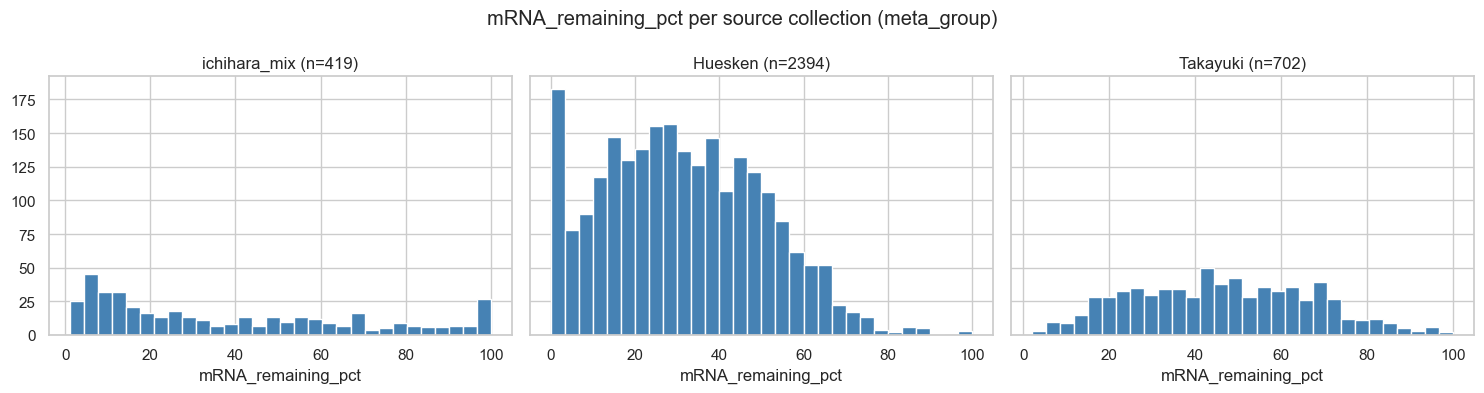

In [11]:
groups = list(hist['meta_group'].dropna().unique())
fig, axes = plt.subplots(1, len(groups), figsize=(5 * len(groups), 4), sharey=True)
axes = np.atleast_1d(axes)
for ax, g in zip(axes, groups):
    sub = pd.to_numeric(hist.loc[hist['meta_group'] == g, 'mRNA_remaining_pct'], errors='coerce').dropna()
    ax.hist(sub, bins=30, color='steelblue')
    ax.set_title(f'{g} (n={len(sub)})')
    ax.set_xlabel('mRNA_remaining_pct')
fig.suptitle('mRNA_remaining_pct per source collection (meta_group)')
plt.tight_layout()
plt.show()

### Target variable: `mRNA_remaining_pct`
- Full distribution
- Grouped by `meta_group` (concentration/source confounds?).
- Dose-response against `siRNA_concentration`.

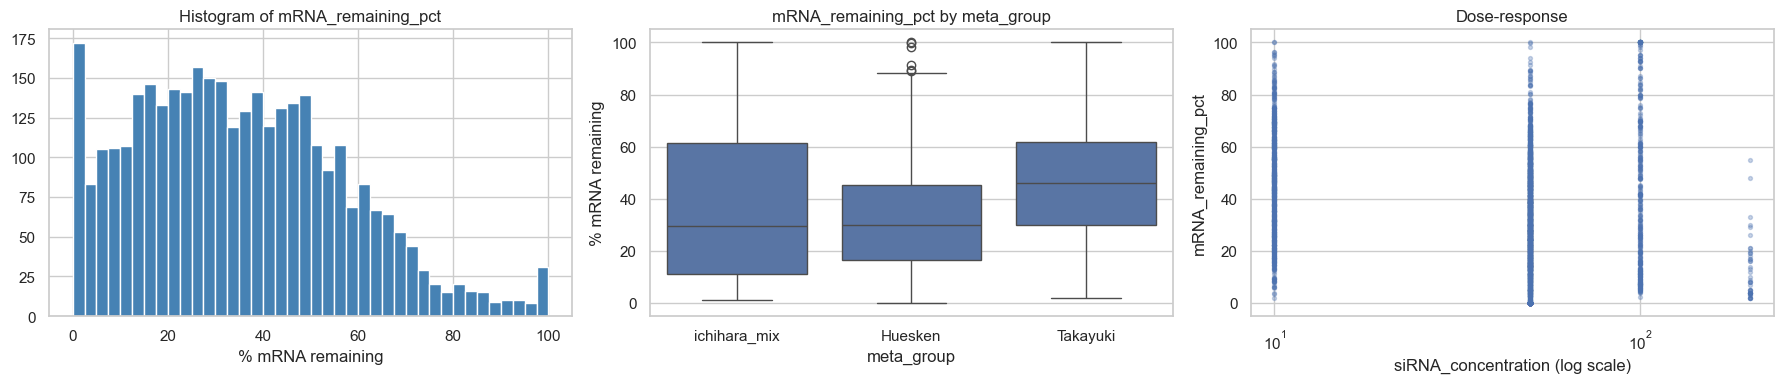

In [12]:
mrp = pd.to_numeric(hist['mRNA_remaining_pct'], errors='coerce')
conc = pd.to_numeric(hist['siRNA_concentration'], errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].hist(mrp.dropna(), bins=40, color='steelblue')
axes[0].set_title('Histogram of mRNA_remaining_pct')
axes[0].set_xlabel('% mRNA remaining')

sns.boxplot(data=hist.assign(_mrp=mrp), x='meta_group', y='_mrp', ax=axes[1])
axes[1].set_title('mRNA_remaining_pct by meta_group')
axes[1].set_ylabel('% mRNA remaining')

axes[2].scatter(conc, mrp, s=8, alpha=0.3)
axes[2].set_xscale('log')
axes[2].set_xlabel('siRNA_concentration (log scale)')
axes[2].set_ylabel('mRNA_remaining_pct')
axes[2].set_title('Dose-response')
plt.tight_layout()
plt.show()

### Sequence-level analysis (guide strand)
- GC-content distribution of the guide strands.
- Positional nucleotide frequency (PWM heatmap) across the 19 positions.
- All guides are 19 nt.

Guide length distribution:
siRNA_guide
19    3515
Name: count, dtype: int64
Mean guide GC content: 52.4%


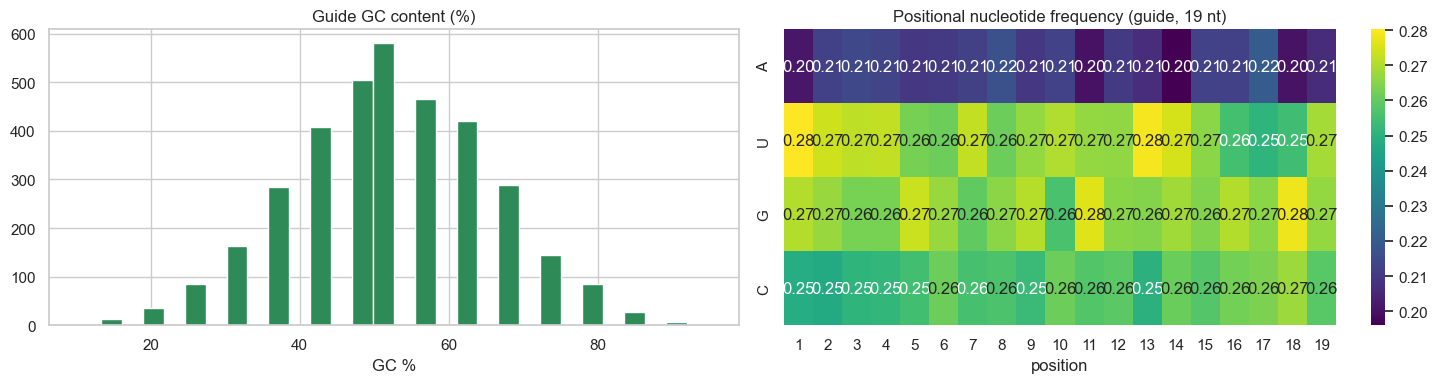

In [13]:
guides = hist['siRNA_guide'].dropna().astype(str)
gc = guides.apply(gc_content)

print('Guide length distribution:')
print(guides.str.len().value_counts())
print(f'Mean guide GC content: {gc.mean():.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
axes[0].hist(gc.dropna(), bins=30, color='seagreen')
axes[0].set_title('Guide GC content (%)')
axes[0].set_xlabel('GC %')

pwm = positional_frequency(guides, length=19)
sns.heatmap(pwm, annot=True, fmt='.2f', cmap='viridis', ax=axes[1])
axes[1].set_title('Positional nucleotide frequency (guide, 19 nt)')
axes[1].set_xlabel('position')
plt.tight_layout()
plt.show()

### Experimental conditions
Cell line, transfection method, time after transfection, concentration, and a count of missing values per column.

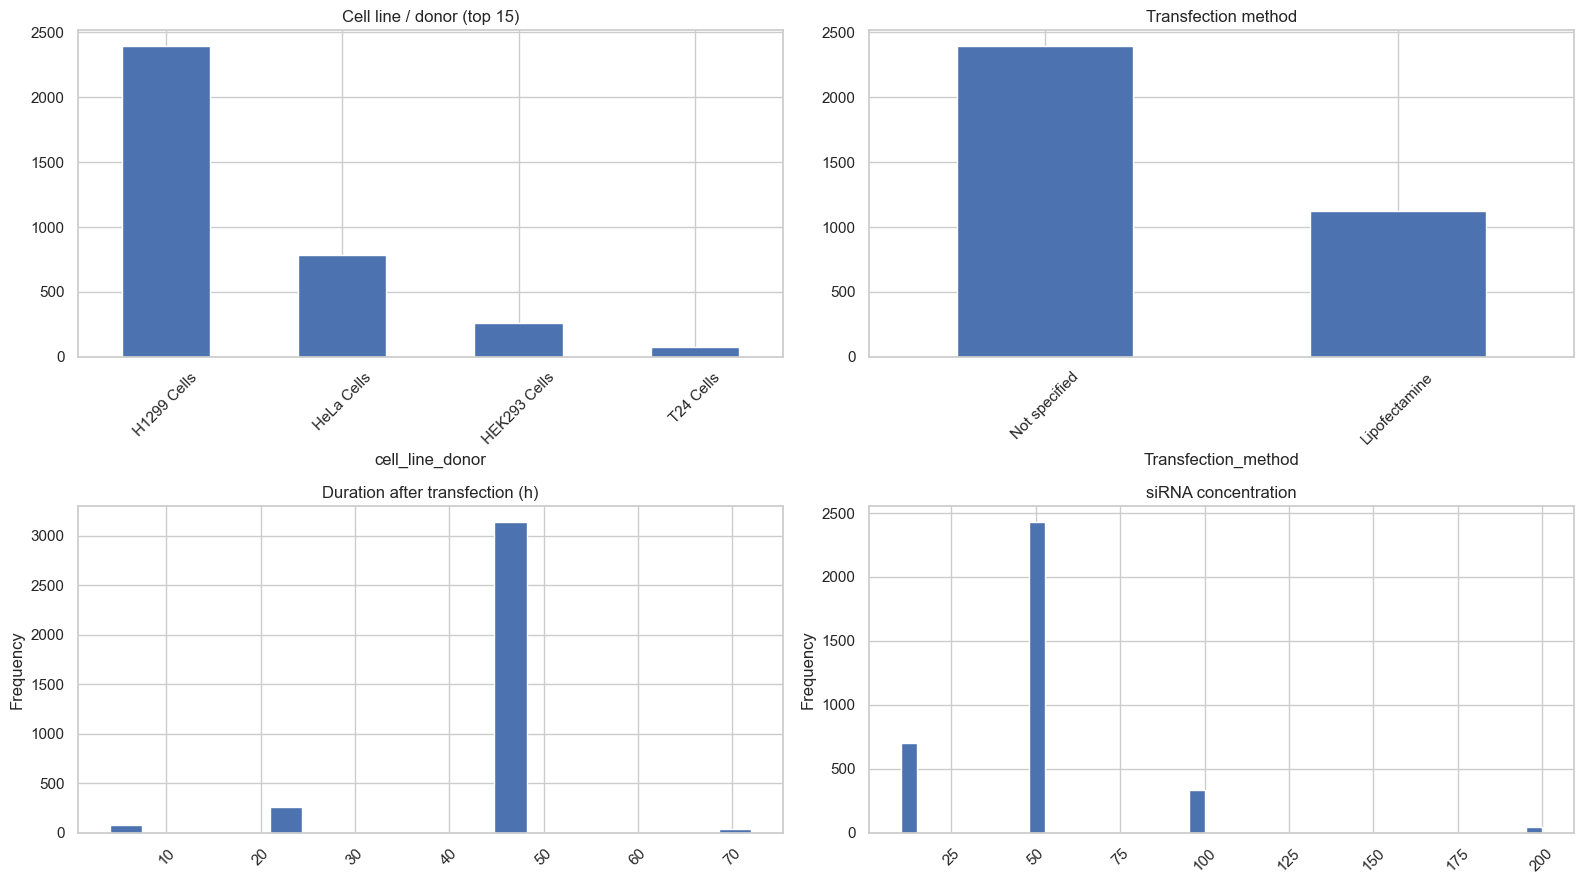

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
hist['cell_line_donor'].value_counts().head(15).plot.bar(ax=axes[0, 0], title='Cell line / donor (top 15)')
hist['Transfection_method'].value_counts(dropna=False).plot.bar(ax=axes[0, 1], title='Transfection method')
pd.to_numeric(hist['Duration_after_transfection_h'], errors='coerce').plot.hist(
    bins=20, ax=axes[1, 0], title='Duration after transfection (h)')
pd.to_numeric(hist['siRNA_concentration'], errors='coerce').plot.hist(
    bins=40, ax=axes[1, 1], title='siRNA concentration')
for ax in axes.flat:
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

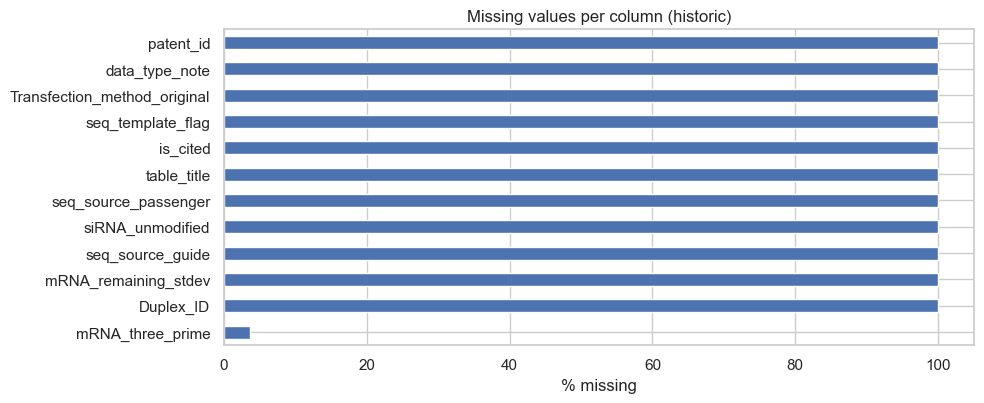

In [15]:
miss = hist.isna().mean().mul(100).sort_values(ascending=False)
miss = miss[miss > 0]
plt.figure(figsize=(10, max(3, 0.35 * len(miss))))
miss.plot.barh()
plt.gca().invert_yaxis()
plt.xlabel('% missing')
plt.title('Missing values per column (historic)')
plt.tight_layout()
plt.show()

### Conclusion
The experimental conditions present in the historic dataset are:

- **Source datasets** (`meta_group`): Huesken, Takayuki, and ichihara_mix.
- **Cell lines / donors**: stored in `cell_line_donor` (e.g. HeLa and others).
- **Transfection method**: predominantly Lipofectamine (plus unspecified ones).
- **siRNA concentration**: numeric, in nM (`concentration_unit`).
- **Duration after transfection**: in hours (`Duration_after_transfection_h`).

Redundancy findings: `test_y` is an exact copy of `mRNA_remaining_pct`, `siRNA` is identical to `siRNA_guide`, `siRNA_list` is just `siRNA_guide` written character-by-character, and `siRNA_passenger_unmod` is the reverse of `siRNA_unmod_passenger`. `mRNA` and `mRNA_five_prime` are *not* identical but share their leading bases. All guide strands are 19 nt with a mean GC content of ~52%.

## Primary dataset
The primary dataset is `CMsiRNA_data_update.tsv`. (The per-gene `patent_dataset_<GENE>.tsv` files are only used in the comparison chapter below.)

In [16]:
primary = pd.read_csv(UPDATE_TSV, sep='\t', low_memory=False)
describe_dataset(primary, 'Primary dataset (CMsiRNA_data_update.tsv)')

Primary dataset (CMsiRNA_data_update.tsv): 43,153 samples (rows) x 26 columns


### Basic stats and column summary

In [17]:
print('Samples (rows):', primary.shape[0])
print('Columns       :', primary.shape[1])

Samples (rows): 43153
Columns       : 26


In [18]:
column_summary(primary)

,column,dtype,n_unique,unique_values_if_lt10,pct_missing
0,ID,object,43078,,0.00
1,patent_ID,object,90,,0.00
2,Authorization_status,object,6,"Granted, Published, Substantive Examination, U...",0.00
3,Accession_number,object,38,,9.34
4,Target_Gene,object,13,,0.00
5,Gene_ID,float64,35,,9.34
6,The_name_of_double_helix,object,14198,,8.53
7,Antisense_seqence,object,11221,,0.00
8,length_anti_sense_strand,float64,14,,7.99
9,Modifications_AntiSense_strand,object,11310,,7.99


Head of the matrix:

In [19]:
primary.head()

,ID,patent_ID,Authorization_status,Accession_number,Target_Gene,Gene_ID,The_name_of_double_helix,Antisense_seqence,length_anti_sense_strand,Modifications_AntiSense_strand,Modification_Types_Antisense_strand,Modification_locations_Antisense_strand,position_Antisense_strand,Sense_seqence,length_sense_strand,Modifications_sense_strand,Modification_Types_Sense_strand,Modification_locations_Sense_strand,position_Sense_strand,Inhibition,SD,Cell_Type,Concentration,Time_of_administration,Title,Modifications_AntiSense_strand_3_5
0,001-01-01-00001-100n-48h-88.00,CN107365771B,Unknown Status,NM_001330729.2,CTNNB1,1499.0,D1,UUAGAAAGCUGAUGGACCAUAACUG,25.0,UUAGAAAGCUGAUGGACCAUAACUG,1*U || 2*U || 3*A || 4*G || 5*A || 6*A || 7*A ...,NaN,NaN,CAGUUAUGGUCCAUCAGCUUUCUAA,25.0,mCmAmGmUmUmAmUGGUCCAUCAGC(mU)mUmUmCmUmAmA,1*2'-O-Methylcytidine || 2*2'-O-Methyladenosin...,Sugar,"1,2,3,4,5,6,7,19,20,21,22,23,24,25",88.0,NaN,Hela,100nM,48h,用于抑制CTNNB1靶基因mRNA表达的寡核酸分子及其成套组合物,GUCAAUACCAGGUAGUCGAAAGAUU
1,001-01-01-00002-100n-48h-90.00,CN107365771B,Unknown Status,NM_001330729.2,CTNNB1,1499.0,D2,UACAAUAGCAGACACCAUCUGAGGA,25.0,UACAAUAGCAGACACCAUCUGAGGA,1*U || 2*A || 3*C || 4*A || 5*A || 6*U || 7*A ...,NaN,NaN,UCCUCAGAUGGUGUCUGCUAUUGUA,25.0,mUmCmCmUmCmAmGAUGGUGUCUGC(mU)mAmUmUmGmUmA,1*2'-O-Methyluridine || 2*2'-O-Methylcytidine ...,Sugar,"1,2,3,4,5,6,7,19,20,21,22,23,24,25",90.0,NaN,Hela,100nM,48h,用于抑制CTNNB1靶基因mRNA表达的寡核酸分子及其成套组合物,AGGAGUCUACCACAGACGAUAACAU
2,001-01-01-00003-100n-48h-90.00,CN107365771B,Unknown Status,NM_001330729.2,CTNNB1,1499.0,D3,UGAACAAGACGUUGACUUGGAUCUG,25.0,UGAACAAGACGUUGACUUGGAUCUG,1*U || 2*G || 3*A || 4*A || 5*C || 6*A || 7*A ...,NaN,NaN,CAGAUCCAAGUCAACGUCUUGUUCA,25.0,mCmAmGmAmUmCmCAAGUCAACGUC(mU)mUmGmUmUmCmA,1*2'-O-Methylcytidine || 2*2'-O-Methyladenosin...,Sugar,"1,2,3,4,5,6,7,19,20,21,22,23,24,25",90.0,NaN,Hela,100nM,48h,用于抑制CTNNB1靶基因mRNA表达的寡核酸分子及其成套组合物,GUCUAGGUUCAGUUGCAGAACAAGU
3,001-01-01-00004-100n-48h-89.00,CN107365771B,Unknown Status,NM_001330729.2,CTNNB1,1499.0,D4,UUUAGUUGCAGCAUCUGAAAGAUUC,25.0,UUUAGUUGCAGCAUCUGAAAGAUUC,1*U || 2*U || 3*U || 4*A || 5*G || 6*U || 7*U ...,NaN,NaN,GAAUCUUUCAGAUGCUGCAACUAAA,25.0,mGmAmAmUmCmUmUUCAGAUGCUGC(mA)mAmCmUmAmAmA,1*2'-O-Methylguanosine || 2*2'-O-Methyladenosi...,Sugar,"1,2,3,4,5,6,7,19,20,21,22,23,24,25",89.0,NaN,Hela,100nM,48h,用于抑制CTNNB1靶基因mRNA表达的寡核酸分子及其成套组合物,CUUAGAAAGUCUACGACGUUGAUUU
4,001-01-01-00005-100n-48h-87.00,CN107365771B,Unknown Status,NM_001330729.2,CTNNB1,1499.0,D5,UUUCGAAUCAAUCCAACAGUAGCCU,25.0,UUUCGAAUCAAUCCAACAGUAGCCU,1*U || 2*U || 3*U || 4*C || 5*G || 6*A || 7*A ...,NaN,NaN,AGGCUACUGUUGGAUUGAUUCGAAA,25.0,mAmGmGmCmUmAmCUGUUGGAUUGA(mU)mUmCmGmAmAmA,1*2'-O-Methyladenosine || 2*2'-O-Methylguanosi...,Sugar,"1,2,3,4,5,6,7,19,20,21,22,23,24,25",87.0,NaN,Hela,100nM,48h,用于抑制CTNNB1靶基因mRNA表达的寡核酸分子及其成套组合物,UCCGAUGACAACCUAACUAAGCUUU


### Nonstandard sequence bases (uncleaned primary dataset)

The checks below use the raw `primary` table before `DataCleaner` row filtering.

In [20]:
import sys
sys.path.insert(0, str(Path('../utils').resolve()))

from sequence_encoding import SequenceEncoder

seq_probe = SequenceEncoder(primary.copy())
seq_probe.check_nonstandard_bases("Sense_seqence")
seq_probe.check_nonstandard_bases("Antisense_seqence")

UCAGCCCCUUAUUGUUAUACGAUUAb
NAG4 || 1*2'-O-Methyl-3'-Phosphorothioate uridine || 2*2'-O-Methylcytidine || 3*2'-O-Methyladenosine || 4*2'-Fluoroguanosine || 5*2'-O-Methylcytidine || 6*2'-Fluorocytidine || 7*2'-O-Methylcytidine || 8*2'-Fluorocytidine || 9*2'-O-Methyluridine || 10*2'-Fluorouridine || 11*2'-Fluoroadenosine || 12*2'-Fluorouridine || 13*2'-O-Methyluridine || 14*2'-Fluoroguanosine || 15*2'-O-Methyluridine || 16*2'-Fluorouridine || 17*2'-O-Methyladenosine || 18*2'-Fluorouridine || 19*2'-O-Methyladenosine || 20*2'-Fluorocytidine || 21*2'-O-Methylguanosine || 22*2'-O-Methyladenosine || 23*2'-O-Methyl-3'-Phosphorothioate uridine || 24*2'-O-Methyluridine || 25*Inverted abasic
UCAGCCCCUUAUUGUUAUACGAAb
NAG4 || 1*2'-O-Methyl-3'-Phosphorothioate uridine || 2*2'-O-Methylcytidine || 3*2'-O-Methyladenosine || 4*2'-Fluoroguanosine || 5*2'-O-Methylcytidine || 6*2'-Fluorocytidine || 7*2'-O-Methylcytidine || 8*2'-Fluorocytidine || 9*2'-O-Methyluridine || 10*2'-Fluorouridine || 11*2'-Fluoroade

{'\n', 'I', 'b', 'c', 'd', 'g', 'u'}

### Simple checks on the nonstandard symbols

Before normalizing the sequences, two assumptions about the nonstandard symbols are verified:

1. Lowercase `b` always appears as part of the subword `Ab` (i.e. it is always preceded by an uppercase `A`).
2. Parentheses `(` and `)` always enclose either `(A2N)` or `(invAb)` (and are always balanced).

In [21]:
import re


def _clean_seqs(series):
    return series.dropna().astype(str).str.replace(" ", "", regex=False)


for col in ["Sense_seqence", "Antisense_seqence"]:
    seqs = _clean_seqs(primary[col])

    # 1) Is lowercase 'b' always preceded by uppercase 'A' (i.e. only as the subword 'Ab')?
    b_not_after_A = [
        s
        for s in seqs
        if any(i == 0 or s[i - 1] != "A" for i, ch in enumerate(s) if ch == "b")
    ]
    print(f"[{col}] sequences where 'b' is NOT preceded by 'A': {len(b_not_after_A)}")

    # 2) Do '(' and ')' always enclose either '(A2N)' or '(invAb)' and stay balanced?
    paren_contents = set()
    for s in seqs:
        paren_contents.update(re.findall(r"\([^)]*\)", s))
    unexpected = paren_contents - {"(A2N)", "(invAb)"}
    balanced = all(s.count("(") == s.count(")") for s in seqs)
    print(f"[{col}] parenthesised subwords found: {sorted(paren_contents)}")
    print(
        f"[{col}] unexpected parenthesised subwords: {sorted(unexpected)} | all balanced: {balanced}"
    )

[Sense_seqence] sequences where 'b' is NOT preceded by 'A': 0
[Sense_seqence] parenthesised subwords found: ['(A2N)', '(invAb)']
[Sense_seqence] unexpected parenthesised subwords: [] | all balanced: True
[Antisense_seqence] sequences where 'b' is NOT preceded by 'A': 0
[Antisense_seqence] parenthesised subwords found: []
[Antisense_seqence] unexpected parenthesised subwords: [] | all balanced: True


### Normalize sequences and re-check

`normalize_sequences` maps the known modification subwords to single-character symbols (`(A2N)` &rarr; `N`, `(invAb)` &rarr; `V`, `Ab` &rarr; `Y`, `g` &rarr; `G`, `c` &rarr; `C`, `u` &rarr; `U`). The nonstandard-base check is then repeated on the normalized sequences.

In [22]:
seq_probe.normalize_sequences()
seq_probe.check_nonstandard_bases("Sense_seqence")
seq_probe.check_nonstandard_bases("Antisense_seqence")

UCAGCCCCUUAUUGUUAUACGAUUY
NAG4 || 1*2'-O-Methyl-3'-Phosphorothioate uridine || 2*2'-O-Methylcytidine || 3*2'-O-Methyladenosine || 4*2'-Fluoroguanosine || 5*2'-O-Methylcytidine || 6*2'-Fluorocytidine || 7*2'-O-Methylcytidine || 8*2'-Fluorocytidine || 9*2'-O-Methyluridine || 10*2'-Fluorouridine || 11*2'-Fluoroadenosine || 12*2'-Fluorouridine || 13*2'-O-Methyluridine || 14*2'-Fluoroguanosine || 15*2'-O-Methyluridine || 16*2'-Fluorouridine || 17*2'-O-Methyladenosine || 18*2'-Fluorouridine || 19*2'-O-Methyladenosine || 20*2'-Fluorocytidine || 21*2'-O-Methylguanosine || 22*2'-O-Methyladenosine || 23*2'-O-Methyl-3'-Phosphorothioate uridine || 24*2'-O-Methyluridine || 25*Inverted abasic
UCAGCCCCUUAUUGUUAUACGAY
NAG4 || 1*2'-O-Methyl-3'-Phosphorothioate uridine || 2*2'-O-Methylcytidine || 3*2'-O-Methyladenosine || 4*2'-Fluoroguanosine || 5*2'-O-Methylcytidine || 6*2'-Fluorocytidine || 7*2'-O-Methylcytidine || 8*2'-Fluorocytidine || 9*2'-O-Methyluridine || 10*2'-Fluorouridine || 11*2'-Fluoroadeno

{'I', 'Y'}

### Further Plots
... to be continued

### Conclusion
The primary dataset uses a completely different (patent-derived) schema from the historic dataset. Key experimental fields are:

- **Target gene**: `Target_Gene` / `Gene_ID` (and `Accession_number`).
- **Sequences**: `Antisense_seqence` (guide) and `Sense_seqence` (passenger), with length and   per-position modification columns.
- **Activity**: `Inhibition` (the target/readout) with `SD` (standard deviation).
- **Conditions**: `Cell_Type`, `Concentration`, `Time_of_administration`.
- **Provenance**: `patent_ID`, `Authorization_status`, `Title`.

## Comparison of the historic and primary dataset

### Do the column names match?
Comparing the column names of the historic dataset against the primary dataset.

In [23]:
hist_cols, prim_cols = set(hist.columns), set(primary.columns)
print(f'Historic columns: {len(hist_cols)} | Primary columns: {len(prim_cols)}')
print('Shared column names      :', sorted(hist_cols & prim_cols) or 'NONE')
print('Only in historic         :', sorted(hist_cols - prim_cols))
print('Only in primary          :', sorted(prim_cols - hist_cols))

Historic columns: 33 | Primary columns: 26
Shared column names      : NONE
Only in historic         : ['Duplex_ID', 'Duration_after_transfection_h', 'Transfection_method', 'Transfection_method_original', 'cell_line_donor', 'concentration_unit', 'data_type_note', 'fold', 'gene_target_species', 'gene_target_symbol_name', 'is_cited', 'mRNA', 'mRNA_five_prime', 'mRNA_remaining_pct', 'mRNA_remaining_stdev', 'mRNA_three_prime', 'meta_group', 'patent_id', 'seq_source_guide', 'seq_source_passenger', 'seq_template_flag', 'siRNA', 'siRNA_concentration', 'siRNA_guide', 'siRNA_list', 'siRNA_passenger', 'siRNA_passenger_list', 'siRNA_passenger_unmod', 'siRNA_unmod_len_diff', 'siRNA_unmod_passenger', 'siRNA_unmodified', 'table_title', 'test_y']
Only in primary          : ['Accession_number', 'Antisense_seqence', 'Authorization_status', 'Cell_Type', 'Concentration', 'Gene_ID', 'ID', 'Inhibition', 'Modification_Types_Antisense_strand', 'Modification_Types_Sense_strand', 'Modification_locations_Antisen

The conceptually equivalent fields map roughly as:

| concept | historic | primary |
|---|---|---|
| target gene | `gene_target_symbol_name` | `Target_Gene` |
| guide strand | `siRNA_guide` | `Antisense_seqence` |
| passenger strand | `siRNA_passenger` | `Sense_seqence` |
| activity readout | `mRNA_remaining_pct` (% remaining) | `Inhibition` (% knockdown) |
| cell line | `cell_line_donor` | `Cell_Type` |
| concentration | `siRNA_concentration` | `Concentration` |
| duration | `Duration_after_transfection_h` | `Time_of_administration` |
| patent id | `patent_id` | `patent_ID` |

### Is `CMsiRNA_data_update.tsv` the merge of the per-gene files?
For each gene that has a `patent_dataset_<GENE>.tsv`,  compare its rows against the rows for that gene in the update file: row counts, ID-set differences, full-row (multiset) equality, and, when rows differ, which columns disagree.

In [24]:
gene_files = sorted(glob.glob(str(PRIMARY_DIR / 'patent_dataset_*.tsv')))
results = []
diff_columns = {}
for f in gene_files:
    gene = Path(f).stem.replace('patent_dataset_', '')
    gdf = pd.read_csv(f, sep='\t', low_memory=False)
    sub = primary[primary['Target_Gene'] == gene]
    cols = list(gdf.columns)
    rows_match = row_multiset(gdf, cols) == row_multiset(sub, cols)
    # Which columns differ (as multisets of values)?
    differing = [c for c in cols if Counter(gdf[c].astype(str)) != Counter(sub[c].astype(str))]
    diff_columns[gene] = differing
    results.append({
        'gene': gene,
        'file_rows': len(gdf),
        'update_rows': len(sub),
        'rows_match': rows_match,
        'differing_columns': ', '.join(differing) if differing else '-',
    })
comparison = pd.DataFrame(results)
comparison

,gene,file_rows,update_rows,rows_match,differing_columns
0,AGT,5326,5326,False,SD
1,ANGPTL3,1118,1118,False,SD
2,APP,2414,2414,False,SD
3,CTNNB1,1285,1285,False,SD
4,HSD17B13,6685,6685,False,SD
5,INHBE,3690,3690,True,-
6,MAPT,1852,1852,True,-
7,MARC1,1414,1414,False,SD
8,MSTN,19,19,True,-
9,PCSK9,3107,3107,False,SD
